# Downloading example data with `emdatabase`

[`emdatabase`](https://github.com/electronmicroscopy/emdatabase) is an index of publicly
hosted electron microscopy datasets and trained model weights. Every entry is a Python
class carrying its metadata; calling `.download()` fetches the file with
[pooch](https://www.fatiando.org/pooch/), verifies its checksum, caches it, and hands back
a path that can be passed straight to a reader.

This tutorial covers picking an entry, downloading it, where the files are kept, the model
weights, and loading both into quantem.

Requirements:
- `emdatabase`, which is installed with quantem (`pip install quantem`)
- `anywidget` for the interactive browser and dataset cards — it comes with
  `quantem[widgets]`, or `pip install anywidget`. Without it they fall back to a plain text
  repr and everything else still runs
- A network connection for the downloading sections

Arthur McCray
Sep 17, 2026

In [1]:
import shutil
import tempfile
from pathlib import Path

import torch

import emdatabase
from emdatabase import data

# somewhere disposable for the examples that write files
demo_dir = Path(tempfile.mkdtemp(prefix="emdatabase_demo_"))
print("download dir :", emdatabase.config.data_dir())

download dir : /home/amccray/.cache/emdatabase


---
## 1. Picking a dataset

The [dataset list in the docs](https://electronmicroscopy.github.io/emdatabase/datasets.html)
is the easiest place to browse what is available. It lists every entry with its description, size,
technique and source.

In a jupyter notebook, `emdatabase.browse()` is the same index displayed through an interactive widget: entries are
grouped by technique, the ones already on disk marked, and there is an easy download button. Displaying the module itself (return `emdatabase`) does the same thing.

In [2]:
emdatabase.browse()

<emdatabase.widget._make_browser_class.<locals>.DatasetBrowser object at 0x7b647f67ffb0>

A single entry renders as a card, its metadata plus a download button. Instantiating the
class fetches nothing unless you run `.download()`.

In [3]:
ds = data.BilayerWS2()
ds

<emdatabase.widget._make_card_class.<locals>.DatasetCard object at 0x7b65e36f65a0>

### Searching from code

`list_datasets()`, `search()` and `filter()` hand back dataset *objects*, so anything a
query returns can be downloaded directly.

`search()` is the browser's search box, callable. It matches one lowercased blob of every
field — name, description, technique, detector, microscope, tags, authors and their
affiliations — and every whitespace-separated term has to appear somewhere, though not
necessarily in the same field.

In [4]:
print("entries in the index  :", len(emdatabase.list_datasets()))
print("of which model weights:", len(emdatabase.list_weights()))
print()

# "jeol" is the microscope and "eels" the technique: different fields, one query
for found in emdatabase.search("jeol eels"):
    techniques = ", ".join(found.metadata.technique)
    print(f"{type(found).__name__:24} {techniques:18} {found.size:>9}")

entries in the index  : 24
of which model weights: 2

CuZnEELSMapping          EELS, STEM          466.1 kB
CuZnHAADF                STEM                 34.0 kB
LSMOLineScan             EELS, STEM           91.9 kB
LSMOLineScanLowLoss      EELS, STEM          138.8 kB
LSMOSTOLineScan          EELS, STEM           42.5 kB
LSMOSTOLineScanLowLoss   EELS, STEM           42.0 kB


`filter()` matches named fields instead. Strings compare exactly but case-insensitively,
`tags` and `authors` test membership, a list means *any of these*, and several criteria are
combined with and. An unknown field raises rather than quietly returning the whole index.

In [5]:
for found in emdatabase.filter(technique="4D-STEM", tags="Strain"):
    print(type(found).__name__, "·", ", ".join(found.metadata.tags))

LayeredCuNb4DSTEM · Nanolaminate, Nanodiffraction, Layered, Orientation Mapping, Strain


### What an entry knows about itself

Everything the YAML declares lives on `ds.metadata`, a frozen dataclass, so
`ds.metadata.technique` and `ds.metadata.authors` work. `print()` it for the whole record
with the unset fields left out. The fields the download machinery needs are also reachable
straight off the object, plus `ds.size` for the formatted version; they are read-only
properties, so to override one, pass it to the constructor.

In [6]:
print(ds.metadata)
print()
for field in ("source", "file", "checksum", "size_bytes", "size"):
    print(f"{field:>11}: {getattr(ds, field)}")

smallPtychography.hspy · 4D-STEM · 12.5 MB
small 4-D STEM dataset of a bilayer WS2. Each Diffraction pattern is only 8x8 pixels so
the dataset is quite small although for simple non iterative ptychography 8x8 pixels
should be sufficient.

               source: https://zenodo.org/records/15490547/files
             checksum: md5:df9376d5c020a23f0f7f51cfe79f303f
detector_manufacturer: Direct Electron
             detector: CeleritasXS
    microscope_vendor: Thermo Fisher Scientific
     microscope_model: Gen 1 Titan
              voltage: 200 kV
              license: CC-BY-4.0
                 tags: Orientation Mapping, Nanocrystals
              authors: Nick Hagopian (University of Wisconsin, Madison)
           size_bytes: 12492298 (12.5 MB)

     source: https://zenodo.org/records/15490547/files
       file: smallPtychography.hspy
   checksum: md5:df9376d5c020a23f0f7f51cfe79f303f
 size_bytes: 12492298
       size: 12.5 MB


---
## 2. Downloading

`download()` runs on a background thread by default and returns immediately. What comes
back is a `DatasetPath`: a `pathlib.Path` pointing at the file's final location, which
blocks the moment anything actually reads the file.

In [7]:
tiny = data.CuZnHAADF()          # 34 kB, the smallest entry in the index

handle = tiny.download()
print("a real Path :", isinstance(handle, Path))
print("done?       :", handle.done, "  failed?", handle.failed)

handle.wait()                    # or handle.result(), which returns a plain Path
print("done?       :", handle.done, "->", handle.result())

a real Path : True
done?       : False   failed? False
done?       : True -> /home/amccray/.cache/emdatabase/CuZn_HAADF.hspy


The blocking happens inside `__fspath__`, which is what `open()`, `.exists()` and every
file reader ultimately go through — that is what makes `read_4dstem(ds.download())` work
without an explicit wait. `background=False` blocks instead, and returns the same type.

`.done` and `.failed` never block and never raise, so a download that fell over can be
checked without re-raising; a failed one also warns. Passing `destination=` overrides the
configured download directory for a single call, and a second call to an entry already on
disk verifies the existing file and returns rather than refetching.

The `checksum` in each entry is enforced by pooch, so a corrupt or truncated download
raises instead of handing back bad data.

In [8]:
broken = data.CuZnHAADF(checksum="md5:" + "0" * 32)
try:
    broken.download(destination=demo_dir, background=False, progressbar=False)
except Exception as error:
    print(f"{type(error).__name__}: {str(error)[:140]}...")

ValueError: MD5 hash of downloaded file (CuZn_HAADF.hspy) does not match the known hash: expected md5:00000000000000000000000000000000 but got b328b4a3c...


### Where the files go

Data lives in named locations. `personal` is the default writable location where downloads
go; every other location is read-only and searched **before** it, so a copy already on a
group drive is reused instead of refetched.

`add_location(path)` adds a shared location, named after the path's last component unless
`name=` is given, and `add_location(path, name="personal")` moves your own download
directory. Both write `~/.config/emdatabase/config.yaml` unless `persist=False` is passed.
On a cluster, an admin can publish one through the environment instead, with no config file
and no write access needed:

```bash
export EMDATABASE_LOCATIONS__GROUP=/group/em_data
```

In [9]:
emdatabase.add_location(demo_dir, name="group", persist=False)

for loc in emdatabase.locations():
    print(f"{loc.kind:9} {loc.name:10} {loc.path}")

emdatabase.remove_location("group", persist=False)

shared    group      /tmp/emdatabase_demo_r9qt1nuj
personal  personal   /home/amccray/.cache/emdatabase


### What is already on disk

`filepath()` returns the local path if the entry is anywhere in the search order, or `None`
if it is not downloaded. `filepaths()` returns every copy, since a shared install and your
own download of the same file can both exist. `delete()` only ever removes your own copy —
an entry that came from a shared location reports `False` and stays put.

In [10]:
for local in emdatabase.filter(downloaded=True):
    print(f"{type(local).__name__:26} {local.size:>9}  {local.filepath()}")

BilayerWS2                   12.5 MB  /home/amccray/.cache/emdatabase/smallPtychography.hspy
CuZnEELSMapping             466.1 kB  /home/amccray/.cache/emdatabase/CuZn_EELS_mapping_tutorial.hspy
CuZnHAADF                    34.0 kB  /home/amccray/.cache/emdatabase/CuZn_HAADF.hspy
FeAlStripes                 382.1 MB  /home/amccray/.cache/emdatabase/FeAl_stripes.zspy
LSMOSTOLineScan              42.5 kB  /home/amccray/.cache/emdatabase/LSMO_STO_linescan.hspy
MOSS6Fig3                    4.36 GB  /home/amccray/.cache/emdatabase/MOSS6Fig3/acquisition_12.xml
TutorialUNet                          /home/amccray/.cache/emdatabase/nn02_unet1_weights.pt


---
## 3. Model weights

Trained weights are entries with `kind: weights` and a `model:` block naming the class,
framework and quantem version they load under. Unlike a dataset, which is one pinned file,
a weights family has dated versions — newest first — and `download()` takes a `version=`
to pin one. The default fetches `latest`.

In [11]:
for w in emdatabase.list_weights():
    print(f"{type(w).__name__:24} {len(w.versions)} version(s)  {w.metadata.model}")
    for version in w.versions:
        print(f"{'':24} {version}")

PeakDetectionPolymers    1 version(s)  ModelInfo(class_='quantem.core.ml.CNN2d', framework='torch', quantem=None)
                         260911
TutorialUNet             2 version(s)  ModelInfo(class_='quantem.core.ml.CNN2d', framework='torch', quantem='>=0.1')
                         260904
                         260902


---
## 4. Loading into quantem

The `DatasetPath` being a `Path` object means that the download handle can go straight into a file reader.

In [12]:
from quantem.core.io.file_readers import read_4dstem
from quantem.core.visualization import show_2d

dset = read_4dstem(data.BilayerWS2().download())
dset

Available datasets:
  Dataset 0: shape (246, 246, 8, 8), ndim=4
Using first 4D dataset at index 0 with shape (246, 246, 8, 8)


Dataset(shape=(246, 246, 8, 8), dtype=float32, name='4D-STEM dataset')
  sampling: [0.14  0.14  4.165 4.165]
  units: ['A^-1', 'A^-1', 'mrad', 'mrad']
  signal units: 'arb. units'

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'BilayerWS2 - mean diffraction pattern'}>)

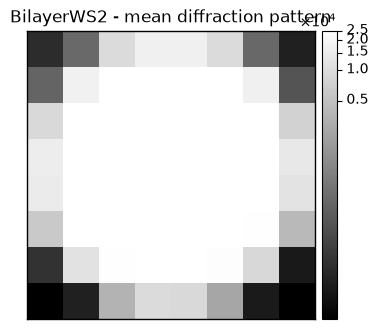

In [13]:
show_2d(
    dset.dp_mean.array,
    title="BilayerWS2 - mean diffraction pattern",
    cbar=True,
    norm="log_auto",
)

Two-dimensional entries load with `read_2d` the same way, and HyperSpy reads the handle
directly too (`hs.load(data.CuZnEELSMapping().download())`).

### Weights into a model

A weights entry is a plain `state_dict`, so it loads into a matching architecture the usual
torch way. Each entry's description says which one — `TutorialUNet` is the small U-Net from
[neural_networks_02_unet.ipynb](neural_networks_02_unet.ipynb), a single-channel
segmentation model, so the architecture it needs is
`CNN2d(in_channels=1, out_channels=1, final_activation=torch.nn.Sigmoid())`.

In [14]:
from quantem.core.ml import CNN2d

weights_path = data.TutorialUNet().download(background=False, progressbar=False)

model = CNN2d(in_channels=1, out_channels=1, final_activation=torch.nn.Sigmoid())
print(model.load_state_dict(torch.load(weights_path, weights_only=True)))
model.eval()

print("parameters :", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    out = model(torch.zeros(1, 1, 128, 128))
print("output     :", tuple(out.shape))

<All keys matched successfully>
parameters : 645009
output     : (1, 1, 128, 128)


See [neural_networks_02_unet.ipynb](neural_networks_02_unet.ipynb) for the training data
these weights were fit to, and for what the segmentation actually looks like on real input.

---
## 5. Adding an entry

An entry is one YAML file in `emdatabase/index/`, keyed by the class name it should
produce. `description`, `source`, `file` and `kind` are required; everything else is
optional metadata. The command-line tool fills in the parts that have to match the uploaded
file — it fetches the size, streams the file to compute its md5, asks for the metadata, and
writes a validated entry:

```bash
python -m emdatabase.new_dataset https://zenodo.org/records/<id>/files/<file>
python -m emdatabase.new_dataset --kind weights https://...
python -m emdatabase.new_dataset --validate emdatabase/index/MyEntry.yaml
```

Then open a pull request adding the file; CI validates it against the shipped JSON schema.
The *new dataset* issue form and the **Add Dataset** page on the
[docs site](https://electronmicroscopy.github.io/emdatabase/) produce the same YAML.

In [15]:
shutil.rmtree(demo_dir, ignore_errors=True)
print("cleaned up", demo_dir)

cleaned up /tmp/emdatabase_demo_r9qt1nuj
